# 2. Feature Engineering

This notebook takes the aggregated 30-minute delay data and builds the final feature matrix used for all models. The input is `B41_aggregated_30min.csv` and the output is `B41_features.csv`, which contains 26 features and 12 regression targets per row.

The feature set is built in layers: we start with time-of-day and calendar features, add weather conditions pulled from a historical API, merge event data for venues along the B41 corridor, and finally compute lag features and the future delay targets. Weather and events are considered relevant predictors. Bus delays on Brooklyn routes are known to spike during rain and large events that generate pedestrian congestion near stops.

Lag features and targets are always computed within each month group separately. The dataset has gaps between months (June, then August, then October, then December) and naively applying `shift()` across the full dataset would mix data across these gaps. Treating the last observation of June as 30 minutes before the first of August. Grouping by month prevents this.

In [21]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

AGG_PATH       = 'B41_aggregated_30min.csv'
EVENTS_PATH    = 'B41_events_timeseries_30min.csv'
OUTPUT_PATH    = 'B41_features.csv'
DISRUPTION_THR = 10
RUSH_HOURS     = list(range(7, 10)) + list(range(16, 20))
LAGS           = [1, 2, 3, 4, 6, 12, 48]   # 30min, 1h, 1.5h, 2h, 3h, 6h, 24h
HORIZONS       = list(range(1, 13))          # t+1 to t+12 (30min to 6h ahead)
NYC_LAT, NYC_LON = 40.6602, -73.9496

## Time Features

The first group of features captures when each observation occurs: hour of day, day of week, whether it is a weekend, and whether it falls in rush hour. Rush hours are defined as 07:00–09:00 and 16:00–19:00, which matches the commuter patterns visible in the notebook 1 validation plots. We also store the numeric month so models can learn seasonal differences between June, August, October, and December.

In [22]:
df = pd.read_csv(AGG_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['hour']        = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek   # 0 = Monday
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['is_rush']     = df['hour'].isin(RUSH_HOURS).astype(int)
df['month_num']   = df['timestamp'].dt.month

print(f'Loaded {len(df):,} windows')
print(f'Months: {sorted(df.month.unique())}')
df.head(3)

Loaded 5,728 windows
Months: ['Aug', 'Dec', 'Jun', 'Oct']


,timestamp,month,mean_delay,median_delay,std_delay,n_obs,pct_disrupted,hour,day_of_week,is_weekend,is_rush,month_num
0,2017-06-01 00:00:00,Jun,5.888889,5.616667,5.319791,21,0.142857,0,3,0,0,6
1,2017-06-01 00:30:00,Jun,3.282456,3.366667,4.111158,19,0.000000,0,3,0,0,6
2,2017-06-01 01:00:00,Jun,2.075000,1.375000,3.171354,10,0.000000,1,3,0,0,6


The dataset covers 5,728 half-hour windows across the four months. The rush hour flag is active for 7 of the 48 daily slots. Covering the windows where the delay patterns we observed earlier are most pronounced.

## Weather

Weather is fetched from the Open-Meteo historical archive API, which provides free hourly data without requiring an API key. We pull temperature, precipitation, and wind speed for the full June–December 2017 period at coordinates corresponding to the Flatbush Avenue corridor.

Since the weather data is hourly and our delay data is 30-minute, we join on a floored timestamp — both windows within the same hour receive the same weather values. This is a reasonable approximation given that weather conditions change slowly relative to a 30-minute interval. We also add a binary `is_raining` flag since even light precipitation tends to affect bus speeds and passenger boarding times.

In [23]:
def fetch_weather(lat, lon, start='2017-06-01', end='2017-12-31'):
    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude':   lat,
        'longitude':  lon,
        'start_date': start,
        'end_date':   end,
        'hourly':     'temperature_2m,precipitation,windspeed_10m',
        'timezone':   'America/New_York'
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()['hourly']
    return pd.DataFrame({
        'hour_key':      pd.to_datetime(data['time']),
        'temperature_c': data['temperature_2m'],
        'precipitation': data['precipitation'],
        'windspeed_kmh': data['windspeed_10m'],
    })

weather = fetch_weather(NYC_LAT, NYC_LON)
weather['is_raining'] = (weather['precipitation'] > 0).astype(int)

print(f'Weather rows: {len(weather):,}')
print(f'Date range  : {weather.hour_key.min()} -> {weather.hour_key.max()}')
print(f'Rain days   : {weather.groupby(weather.hour_key.dt.date)["is_raining"].max().sum()}')
weather.head(3)

Weather rows: 5,136
Date range  : 2017-06-01 00:00:00 -> 2017-12-31 23:00:00
Rain days   : 115


,hour_key,temperature_c,precipitation,windspeed_kmh,is_raining
0,2017-06-01 00:00:00,16.6,0.0,7.2,0
1,2017-06-01 01:00:00,17.6,0.0,11.6,0
2,2017-06-01 02:00:00,17.4,0.0,11.0,0


In [24]:
# Join on hour
df['hour_key'] = df['timestamp'].dt.floor('1h')  
df = df.merge(weather, on='hour_key', how='left')
df.drop(columns='hour_key', inplace=True)

print(f'After weather merge: {len(df):,} rows')
print(f'Weather nulls: {df[["temperature_c","precipitation","windspeed_kmh"]].isnull().sum().to_dict()}')

After weather merge: 5,728 rows
Weather nulls: {'temperature_c': 0, 'precipitation': 0, 'windspeed_kmh': 0}


Out of the 214 days in the period, 115 had at least some recorded precipitation. That is a substantial share of the dataset, suggesting weather features could carry meaningful predictive signal, especially for disruptions triggered by heavier rain events.

## Events

The B41 route passes several venues that host large events. When events are active, bus delays tend to increase due to pedestrian congestion around nearby stops and general traffic buildup in the area.

The events dataset provides binary flags per 30-minute window for five locations along the route. We also create an `event_any` column which is 1 if any venue is active. This is simple on/off signal that may be easier for linear models to use than the individual location flags.

In [25]:
events = pd.read_csv(EVENTS_PATH)
events['timestamp'] = pd.to_datetime(events['timestamp'])

events = events.rename(columns={
    'FLATBUSH AV/PROSPECT PARK ENT': 'event_prospect_park',
    'LIVINGSTON ST/NEVINS ST':       'event_livingston',
    'FLATBUSH AV/BERGEN ST':         'event_bergen',
    'CADMAN PLZ W/MONTAGUE ST':      'event_cadman',
    'FLATBUSH AV/PLAZA ST E':        'event_plaza_st',
})

event_cols = ['event_prospect_park', 'event_livingston', 'event_bergen',
              'event_cadman', 'event_plaza_st']
events['event_any'] = events[event_cols].max(axis=1)

print('Active slots per station:')
print(events[event_cols + ['event_any']].sum().astype(int))

df = df.merge(events, on='timestamp', how='left')
for col in event_cols + ['event_any']:
    df[col] = df[col].fillna(0).astype(int)

print(f'\nAfter events merge: {len(df):,} rows')

Active slots per station:
event_prospect_park    2916
event_livingston        569
event_bergen            158
event_cadman            249
event_plaza_st          870
event_any              3229
dtype: int64

After events merge: 5,728 rows


Prospect Park is by far the most active location with 2,916 flagged slots. Event conditions are not a rare exception for this route but rather a normal part of its operating environment.

## Lag Features and Targets

Lag features capture the recent delay history: `lag_1` is the delay 30 minutes ago, `lag_2` is 1 hour ago, and so on up to `lag_48` which is the same time slot from the previous day (24 hours back). The 24-hour lag is particularly useful because bus delay patterns tend to repeat on a daily cycle. If the 17:00 slot was heavily delayed yesterday, it is more likely to be delayed today as well.

We also add a `delay_trend` feature computed as `lag_1 - lag_2`, capturing whether conditions are currently worsening or recovering. A positive value means delays are rising; negative means the route is recovering.

The 12 regression targets (`mean_delay_t1` through `mean_delay_t12`) are the future delay values the models will predict, from t+30min to t+6h. They are computed as `shift(-h)` within each month group to avoid any cross-month leakage.

In [26]:
def add_lags_and_targets(group):
    group = group.sort_values('timestamp').copy()
    for lag in LAGS:
        group[f'lag_{lag}'] = group['mean_delay'].shift(lag)
    group['delay_trend'] = group['lag_1'] - group['lag_2']
    for h in HORIZONS:
        group[f'mean_delay_t{h}'] = group['mean_delay'].shift(-h)
    return group

blocks = []
for month, group in df.groupby('month'):
    blocks.append(add_lags_and_targets(group))

df = pd.concat(blocks).reset_index(drop=True)

lag_cols    = [f'lag_{l}' for l in LAGS]
target_cols = [f'mean_delay_t{h}' for h in HORIZONS]
print('Null counts (expected only at month boundaries):')
print(df[lag_cols + ['delay_trend'] + target_cols].isnull().sum())

Null counts (expected only at month boundaries):
lag_1               4
lag_2               8
lag_3              12
lag_4              16
lag_6              24
lag_12             48
lag_48            192
delay_trend         8
mean_delay_t1       4
mean_delay_t2       8
mean_delay_t3      12
mean_delay_t4      16
mean_delay_t5      20
mean_delay_t6      24
mean_delay_t7      28
mean_delay_t8      32
mean_delay_t9      36
mean_delay_t10     40
mean_delay_t11     44
mean_delay_t12     48
dtype: int64


The null counts are exactly what we expect: `lag_1` has 4 nulls (one per month — the first window of each block has no predecessor), and `lag_48` has 192 nulls (48 steps times 4 months). These boundary rows will be removed in the final cleaning step.

## Disruption Persistence

Before finalising the features, we compute a statistic that directly motivates the prediction horizon and the resilience framing of the problem. The question is: once the B41 route enters a disrupted state (mean delay above 10 minutes), how long does that disruption typically last?

If disruptions resolve within a few minutes, a 6-hour prediction horizon would add little practical value. But if they persist for an hour or more, even a 30-minute early warning gives operators meaningful time to adjust service, pre-position resources, or communicate with passengers before conditions deteriorate further.

In [27]:
def compute_persistence(group, max_horizon=8):
    group = group.sort_values('timestamp').copy()
    disrupted = (group['mean_delay'] > DISRUPTION_THR).values
    probs = {}
    for h in range(1, max_horizon + 1):
        curr   = disrupted[:-h]
        future = disrupted[h:]
        probs[h * 30] = float(future[curr].mean()) if curr.sum() > 0 else np.nan
    return pd.Series(probs)

pers_blocks = []
for month, group in df.groupby('month'):
    s = compute_persistence(group)
    s.name = month
    pers_blocks.append(s)

persistence      = pd.DataFrame(pers_blocks)
persistence_mean = persistence.mean()

print('P(still disrupted | disrupted now) by minutes ahead:')
for minutes, prob in persistence_mean.items():
    print(f'  +{int(minutes):3d} min: {prob:.1%}')

P(still disrupted | disrupted now) by minutes ahead:
  + 30 min: 80.5%
  + 60 min: 71.3%
  + 90 min: 65.7%
  +120 min: 61.4%
  +150 min: 57.3%
  +180 min: 53.2%
  +210 min: 49.6%
  +240 min: 45.8%


The overall average starts at 80.5% at 30 minutes and decays gradually, crossing the 50% mark only around 3.5 hours after onset. Disruptions are not short-lived spikes. The route tends to stay in a degraded state for a long time once it enters one.

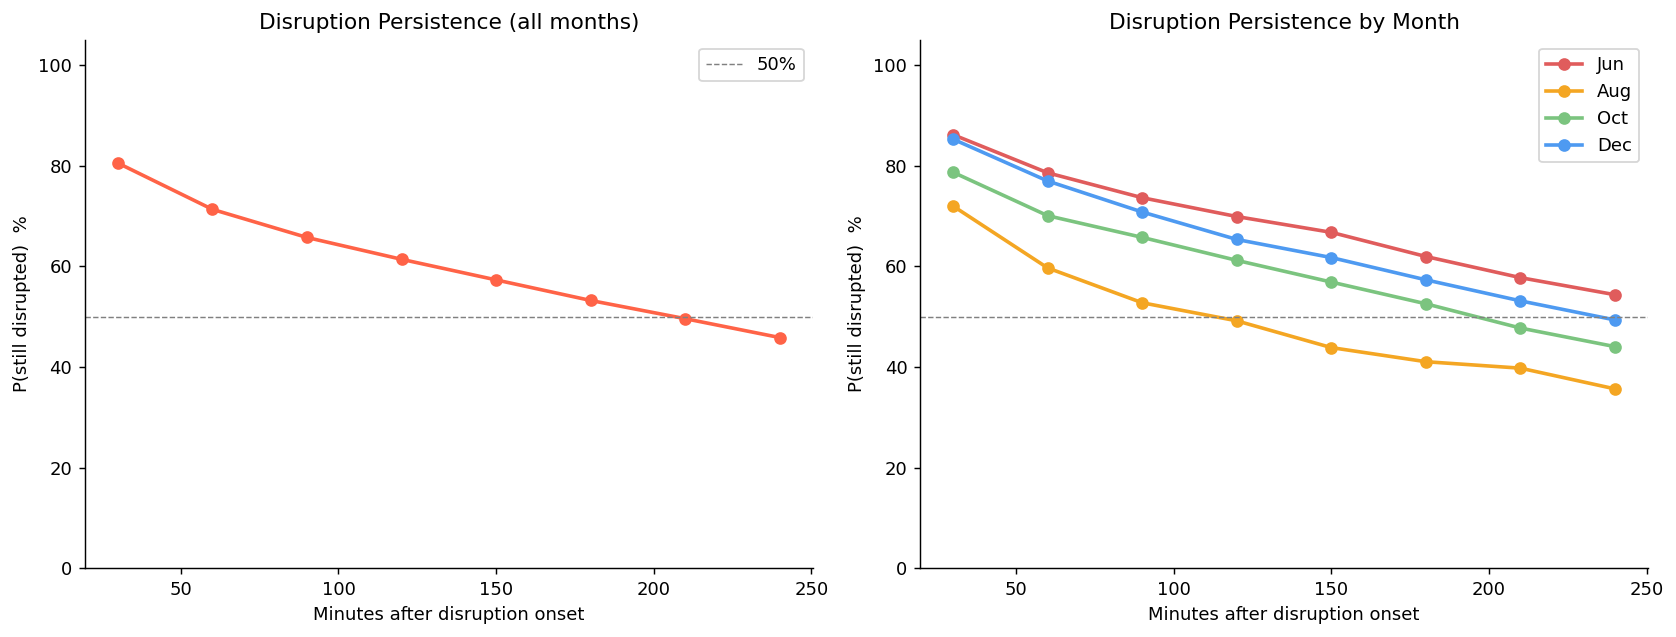


Key finding: once disrupted, B41 remains disrupted after 60 min in 71% of cases
                                                        after 90 min in 66% of cases
→ 6-hour early warning system targets persistent disruptions with sufficient lead time.


In [28]:
month_order = ['Jun', 'Aug', 'Oct', 'Dec']
colors_m    = {'Jun': '#e05c5c', 'Aug': '#f4a623', 'Oct': '#7bc47f', 'Dec': '#4e9af1'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(persistence_mean.index, persistence_mean.values * 100,
        marker='o', color='tomato', linewidth=2)
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='50%')
ax.set_xlabel('Minutes after disruption onset')
ax.set_ylabel('P(still disrupted)  %')
ax.set_title('Disruption Persistence (all months)')
ax.set_ylim(0, 105)
ax.legend()

ax = axes[1]
for m in month_order:
    grp  = df[df['month'] == m]
    pers = compute_persistence(grp)
    ax.plot(pers.index, pers.values * 100, marker='o', label=m,
            color=colors_m[m], linewidth=2)

ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Minutes after disruption onset')
ax.set_ylabel('P(still disrupted)  %')
ax.set_title('Disruption Persistence by Month')
ax.set_ylim(0, 105)
ax.legend()

plt.tight_layout()
plt.savefig('disruption_persistence.png', bbox_inches='tight')
plt.show()

p60 = persistence_mean.get(60, np.nan)
p90 = persistence_mean.get(90, np.nan)
print(f'\nKey finding: once disrupted, B41 remains disrupted after 60 min in {p60:.0%} of cases')
print(f'                                                        after 90 min in {p90:.0%} of cases')
print('→ 6-hour early warning system targets persistent disruptions with sufficient lead time.')

The monthly breakdown (right panel) reveals an important difference in disruption character across seasons. August has the lowest persistence — only 36% at 4 hours. Consistent with it being the lightest traffic month. June and December both start near 86% and stay above 50% throughout the full 4-hour window, meaning disruptions in those months are considerably harder to shake off.

## Final Dataset

We now select the 26 feature columns and 12 target columns, drop any rows with NaN values in these columns (the boundary rows from lag and target computation), and save the result. The final shape should be close to 5,488 rows — about 240 fewer than the raw aggregated data.

In [29]:
FEATURE_COLS = [
    # Current window state
    'mean_delay', 'std_delay', 'pct_disrupted',
    # Lag history
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_6', 'lag_12', 'lag_48',
    # Momentum: positive = delay rising, negative = recovering
    'delay_trend',
    # Calendar
    'hour', 'day_of_week', 'is_weekend', 'is_rush', 'month_num',
    # Weather
    'temperature_c', 'precipitation', 'windspeed_kmh', 'is_raining',
    # Events
    'event_prospect_park', 'event_livingston', 'event_bergen',
    'event_cadman', 'event_plaza_st', 'event_any',
]

target_cols = [f'mean_delay_t{h}' for h in HORIZONS]
required    = FEATURE_COLS + target_cols
before      = len(df)
df_clean    = df.dropna(subset=required).copy()

print(f'Rows before/after NaN drop: {before:,} → {len(df_clean):,}')
print(f'Dropped: {before - len(df_clean):,} rows (lag/target boundaries)')
print(f'\nFinal rows per month:')
print(df_clean.groupby('month')['timestamp'].count())
print(f'\nTarget statistics (mean delay by horizon):')
stats = df_clean[target_cols].mean().round(2)
stats.index = [f't+{h*30}min' for h in HORIZONS]
print(stats.to_string())
print(f'\nDisruption rate by horizon (predicted_delay > 10 min):')
rates = (df_clean[target_cols] > DISRUPTION_THR).mean().round(3)
rates.index = [f't+{h*30}min' for h in HORIZONS]
print(rates.to_string())
print(f'\nFeature count: {len(FEATURE_COLS)}')

Rows before/after NaN drop: 5,728 → 5,488
Dropped: 240 rows (lag/target boundaries)

Final rows per month:
month
Aug    1297
Dec    1403
Jun    1377
Oct    1411
Name: timestamp, dtype: int64

Target statistics (mean delay by horizon):
t+30min     7.46
t+60min     7.47
t+90min     7.47
t+120min    7.48
t+150min    7.48
t+180min    7.49
t+210min    7.49
t+240min    7.50
t+270min    7.50
t+300min    7.51
t+330min    7.51
t+360min    7.52

Disruption rate by horizon (predicted_delay > 10 min):
t+30min     0.259
t+60min     0.260
t+90min     0.260
t+120min    0.260
t+150min    0.261
t+180min    0.261
t+210min    0.262
t+240min    0.262
t+270min    0.263
t+300min    0.263
t+330min    0.264
t+360min    0.264

Feature count: 26


The target mean delay is nearly identical across all 12 horizons (7.46 to 7.52 minutes). This makes sense because the overall average does not depend on how far ahead you are predicting. The disruption rate is also stable at around 26% across horizons. What varies across horizons is prediction difficulty, which the model evaluation in the next notebooks will quantify.

In [30]:
save_cols = ['timestamp', 'month'] + FEATURE_COLS + target_cols
out = df_clean[save_cols].sort_values('timestamp').reset_index(drop=True)
out.to_csv(OUTPUT_PATH, index=False)

print(f'Saved  → {OUTPUT_PATH}')
print(f'Shape  : {out.shape}')
print(f'Columns: {save_cols}')
out.head(4)

Saved  → B41_features.csv
Shape  : (5488, 40)
Columns: ['timestamp', 'month', 'mean_delay', 'std_delay', 'pct_disrupted', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_6', 'lag_12', 'lag_48', 'delay_trend', 'hour', 'day_of_week', 'is_weekend', 'is_rush', 'month_num', 'temperature_c', 'precipitation', 'windspeed_kmh', 'is_raining', 'event_prospect_park', 'event_livingston', 'event_bergen', 'event_cadman', 'event_plaza_st', 'event_any', 'mean_delay_t1', 'mean_delay_t2', 'mean_delay_t3', 'mean_delay_t4', 'mean_delay_t5', 'mean_delay_t6', 'mean_delay_t7', 'mean_delay_t8', 'mean_delay_t9', 'mean_delay_t10', 'mean_delay_t11', 'mean_delay_t12']


,timestamp,month,mean_delay,std_delay,pct_disrupted,lag_1,lag_2,lag_3,lag_4,lag_6,...,mean_delay_t3,mean_delay_t4,mean_delay_t5,mean_delay_t6,mean_delay_t7,mean_delay_t8,mean_delay_t9,mean_delay_t10,mean_delay_t11,mean_delay_t12
0,2017-06-02 00:00:00,Jun,11.004386,11.804078,0.421053,17.091667,8.411404,9.452381,6.931481,9.008824,...,1.847917,2.046970,1.561111,0.477778,3.162222,4.253125,1.668750,0.709259,5.102778,2.676190
1,2017-06-02 00:30:00,Jun,7.752778,8.567283,0.277778,11.004386,17.091667,8.411404,9.452381,7.327519,...,2.046970,1.561111,0.477778,3.162222,4.253125,1.668750,0.709259,5.102778,2.676190,3.292537
2,2017-06-02 01:00:00,Jun,6.271667,3.932831,0.100000,7.752778,11.004386,17.091667,8.411404,6.931481,...,1.561111,0.477778,3.162222,4.253125,1.668750,0.709259,5.102778,2.676190,3.292537,4.657471
3,2017-06-02 01:30:00,Jun,1.847917,3.256732,0.000000,6.271667,7.752778,11.004386,17.091667,9.452381,...,0.477778,3.162222,4.253125,1.668750,0.709259,5.102778,2.676190,3.292537,4.657471,3.692029
